In [ ]:
import pandas as pd

# Cargar el dataset
archivo = "/content/drive/MyDrive/ASE/JuegosOlimpicos CD.csv"
df = pd.read_csv(archivo)

# Mostrar las primeras 5 filas del dataset
print(df.head())

# Mostrar información general sobre las columnas y tipos de datos
print(df.info())


   ID                      Name Sex Age Height Weight            Team  NOC  \
0   1                 A Dijiang   M  24    180     80            Chi.  CHN   
1   2                  A Lamusi   M  23    170     60            Chi.  CHN   
2   3        Gun.r Nielsen Aaby   M  24      .      .         Denmark  DEN   
3   4       Edgar Linde.u Aabye   M  34      .      .  Denmark/Sweden  DEN   
4   5  Christine Jacoba Aaftink   F  21    185     82     Netherlands  NED   

         Games  Year  Season       City          Sport  \
0  1992 Summer  1992  Summer   Barcelo.     Basketball   
1  2012 Summer  2012  Summer     London           Judo   
2  1920 Summer  1920  Summer  Antwerpen       Football   
3  1900 Summer  1900  Summer      Paris     Tug-Of-War   
4  1988 Winter  1988  Winter    Calgary  Speed Skating   

                              Event Medal  
0       Basketball Men's Basketball     .  
1      Judo Men's Extra-Lightweight     .  
2           Football Men's Football     .  
3     

In [ ]:
# Reemplazar valores "." por NaN y convertir a tipo numérico
df["Height"] = pd.to_numeric(df["Height"], errors="coerce")
df["Weight"] = pd.to_numeric(df["Weight"], errors="coerce")

# Eliminar filas con valores nulos en Height o Weight
df = df.dropna(subset=["Height", "Weight"])

# Confirmar que las columnas ahora son numéricas
print(df[["Height", "Weight"]].info())

# Mostrar algunas filas después de la limpieza
print(df.head())


<class 'pandas.core.frame.DataFrame'>
Index: 206853 entries, 0 to 271115
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Height  206853 non-null  float64
 1   Weight  206853 non-null  float64
dtypes: float64(2)
memory usage: 4.7 MB
None
   ID                      Name Sex Age  Height  Weight         Team  NOC  \
0   1                 A Dijiang   M  24   180.0    80.0         Chi.  CHN   
1   2                  A Lamusi   M  23   170.0    60.0         Chi.  CHN   
4   5  Christine Jacoba Aaftink   F  21   185.0    82.0  Netherlands  NED   
5   5  Christine Jacoba Aaftink   F  21   185.0    82.0  Netherlands  NED   
6   5  Christine Jacoba Aaftink   F  25   185.0    82.0  Netherlands  NED   

         Games  Year  Season         City          Sport  \
0  1992 Summer  1992  Summer     Barcelo.     Basketball   
1  2012 Summer  2012  Summer       London           Judo   
4  1988 Winter  1988  Winter      Calgary  Speed Skatin

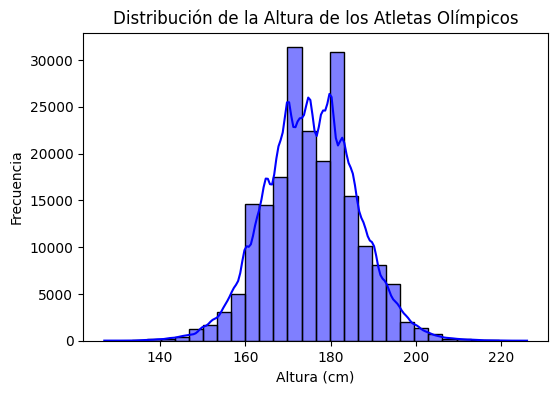

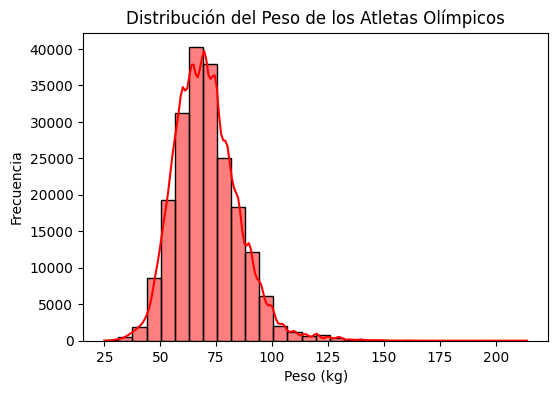

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de altura
plt.figure(figsize=(6, 4))
sns.histplot(df["Height"], bins=30, kde=True, color="blue")
plt.xlabel("Altura (cm)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la Altura de los Atletas Olímpicos")
plt.show()

# Histograma de peso
plt.figure(figsize=(6, 4))
sns.histplot(df["Weight"], bins=30, kde=True, color="red")
plt.xlabel("Peso (kg)")
plt.ylabel("Frecuencia")
plt.title("Distribución del Peso de los Atletas Olímpicos")
plt.show()


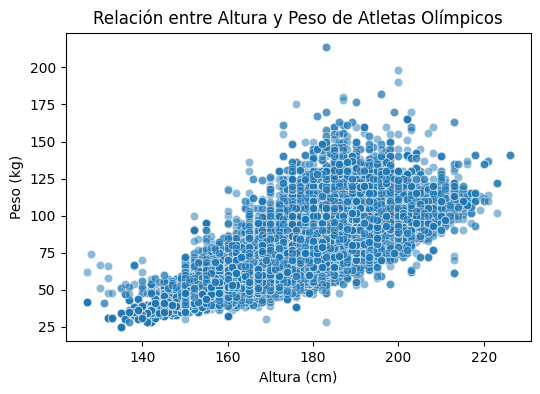

In [ ]:
# Gráfico de dispersión
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["Height"], y=df["Weight"], alpha=0.5)
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")
plt.title("Relación entre Altura y Peso de Atletas Olímpicos")
plt.show()


In [ ]:
import statsmodels.api as sm
import numpy as np

# Definir las variables
X = df["Height"]  # Variable independiente (altura)
y = df["Weight"]  # Variable dependiente (peso)

# Agregar constante (intercepto) al modelo
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal
modelo = sm.OLS(y, X).fit()

# Mostrar resultados
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.634
Model:                            OLS   Adj. R-squared:                  0.634
Method:                 Least Squares   F-statistic:                 3.582e+05
Date:                Tue, 11 Mar 2025   Prob (F-statistic):               0.00
Time:                        13:43:47   Log-Likelihood:            -7.4029e+05
No. Observations:              206853   AIC:                         1.481e+06
Df Residuals:                  206851   BIC:                         1.481e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -119.1211      0.318   -374.976      0.0

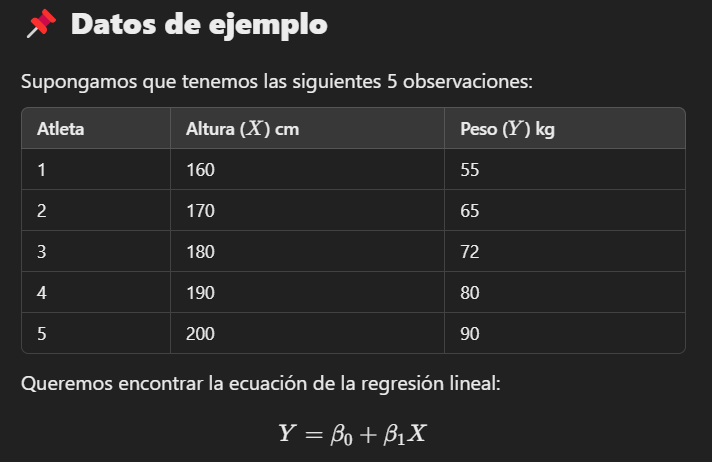

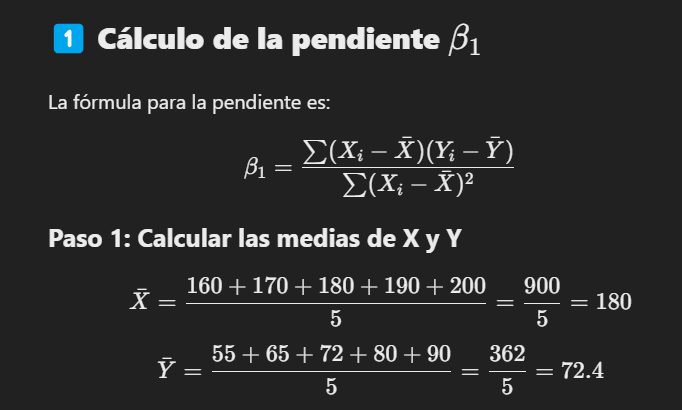

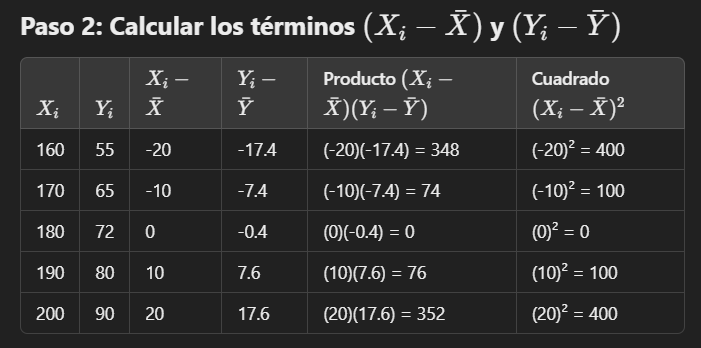

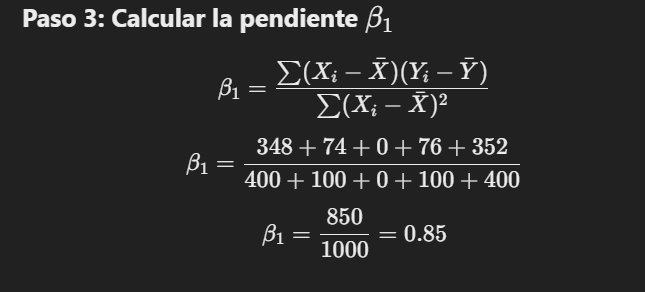

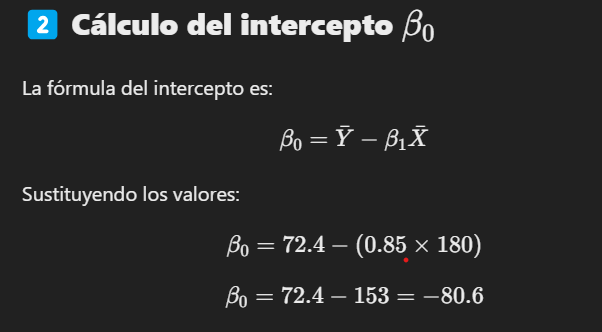

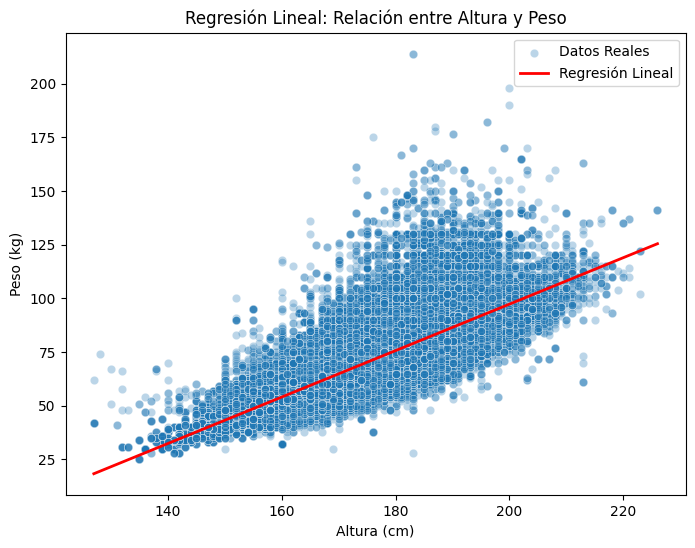

In [ ]:
# Definir los coeficientes de la regresión lineal
beta_0 = -119.1211
beta_1 = 1.0823

# Crear valores de altura para la recta
x = np.linspace(df["Height"].min(), df["Height"].max(), 100)  # Rango de alturas
y = beta_0 + beta_1 * x  # Ecuación de la recta

# Graficar los puntos originales
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Height"], y=df["Weight"], alpha=0.3, label="Datos Reales")

# Graficar la recta de regresión
plt.plot(x, y, color="red", linewidth=2, label="Regresión Lineal")

# Personalizar el gráfico
plt.xlabel("Altura (cm)")
plt.ylabel("Peso (kg)")
plt.title("Regresión Lineal: Relación entre Altura y Peso")
plt.legend()
plt.show()




